[Набор данных для подсчета и классификации клеток крови](https://github.com/Shenggan/BCCD_Dataset "ссылка на ГитХаб")

## `Получение данных|Скачивание репозитория из github`.

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.2 MB/s eta 0:00:00


In [2]:
# Скачиваем репозиторий
%%shell
git clone https://github.com/Shenggan/BCCD_Dataset.git
cd BCCD_Dataset

Cloning into 'BCCD_Dataset'...
remote: Enumerating objects: 800, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 800 (delta 8), reused 6 (delta 6), pack-reused 789 (from 1)
Receiving objects: 100% (800/800), 7.39 MiB | 25.55 MiB/s, done.
Resolving deltas: 100% (379/379), done.


In [3]:
# /content/BCCD_Dataset/BCCD/Annotations - Аннотации в формате Pascal VOC (XML)координаты ground truth bounding boxes (разметка-истинные рамки) и классы: RBC, WBC, Platelets
# /content/BCCD_Dataset/BCCD/JPEGImages -  Исходные изображения (200+ фото мазков крови
# /content/BCCD_Dataset/BCCD/ImageSets/Main - Готовые разбиения на train/test/val (списки файлов для обучения, теста и валидации)

## `Обработка и анализ проблемных файлов`.

In [4]:
import os
import numpy as np
import xml.etree.ElementTree as ET
from PIL import Image
from collections import defaultdict

def check_bounding_boxes(annotations_dir, images_dir=None, file_list=None):
    """
    Проверяет все аннотации на наличие невалидных bounding boxes.

    Args:
        annotations_dir: путь к папке с XML аннотациями
        images_dir: путь к папке с изображениями (опционально)
        file_list: путь к txt файлу со списком файлов (опционально)
    """

    problematic_images = []     # изображения с проблемными боксами
    stats = defaultdict(int)    # статистика

    # --- Получаем список файлов ---
    if file_list and os.path.exists(file_list):
        with open(file_list, 'r') as f:
            filenames = [line.strip() for line in f.readlines()]
        xml_files = [os.path.join(annotations_dir, f + '.xml') for f in filenames]
        print(f"📂 Загружено из списка: {len(xml_files)} файлов")
    else:
        xml_files = [
            os.path.join(annotations_dir, f)
            for f in os.listdir(annotations_dir)
            if f.endswith('.xml')
        ]
        print(f"📂 Найдено XML файлов: {len(xml_files)}")

    # --- Проверяем каждый файл ---
    for xml_path in xml_files:

        if not os.path.exists(xml_path):
            print(f"⚠️  Файл не найден: {xml_path}")
            stats['missing_files'] += 1
            continue

        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
        except ET.ParseError as e:
            print(f"❌ Ошибка парсинга {xml_path}: {e}")
            stats['parse_errors'] += 1
            continue

        image_name = os.path.basename(xml_path).replace('.xml', '')
        bad_boxes = []
        all_boxes = []

        # --- Парсим все боксы ---
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            class_name = obj.find('name').text if obj.find('name') is not None else 'unknown'

            if bndbox is None:
                continue

            try:
                x1 = float(bndbox.find('xmin').text)
                y1 = float(bndbox.find('ymin').text)
                x2 = float(bndbox.find('xmax').text)
                y2 = float(bndbox.find('ymax').text)
            except (AttributeError, TypeError, ValueError) as e:
                print(f"  ⚠️  Ошибка чтения координат в {image_name}: {e}")
                stats['coord_errors'] += 1
                continue

            width  = x2 - x1
            height = y2 - y1

            all_boxes.append({
                'class': class_name,
                'coords': (x1, y1, x2, y2),
                'width': width,
                'height': height
            })

            # --- Проверяем на проблемы ---
            issues = []

            if x1 == x2:
                issues.append(f"нулевая ШИРИНА (x1==x2=={x1})")
                stats['zero_width'] += 1

            if y1 == y2:
                issues.append(f"нулевая ВЫСОТА (y1==y2=={y1})")
                stats['zero_height'] += 1

            if x2 < x1:
                issues.append(f"ОТРИЦАТЕЛЬНАЯ ширина (x1={x1} > x2={x2})")
                stats['negative_width'] += 1

            if y2 < y1:
                issues.append(f"ОТРИЦАТЕЛЬНАЯ высота (y1={y1} > y2={y2})")
                stats['negative_height'] += 1

            if x1 < 0 or y1 < 0 or x2 < 0 or y2 < 0:
                issues.append(f"ОТРИЦАТЕЛЬНЫЕ координаты ({x1}, {y1}, {x2}, {y2})")
                stats['negative_coords'] += 1

            if issues:
                bad_boxes.append({
                    'class': class_name,
                    'coords': (x1, y1, x2, y2),
                    'issues': issues
                })

        stats['total_boxes'] += len(all_boxes)

        # --- Сохраняем проблемные ---
        if bad_boxes:
            problematic_images.append({
                'image_name': image_name,
                'xml_path': xml_path,
                'total_boxes': len(all_boxes),
                'bad_boxes': bad_boxes
            })
            stats['problematic_images'] += 1
            stats['total_bad_boxes'] += len(bad_boxes)

    # =============================================
    # --- ВЫВОД РЕЗУЛЬТАТОВ ---
    # =============================================
    print("\n" + "="*60)
    print("📊 СТАТИСТИКА ПРОВЕРКИ")
    print("="*60)
    print(f"  Всего файлов проверено : {len(xml_files)}")
    print(f"  Всего боксов           : {stats['total_boxes']}")
    print(f"  Проблемных изображений : {stats['problematic_images']}")
    print(f"  Всего плохих боксов    : {stats['total_bad_boxes']}")
    print(f"  — нулевая ширина       : {stats['zero_width']}")
    print(f"  — нулевая высота       : {stats['zero_height']}")
    print(f"  — отрицательная ширина : {stats['negative_width']}")
    print(f"  — отрицательная высота : {stats['negative_height']}")
    print(f"  — отриц. координаты   : {stats['negative_coords']}")

    if problematic_images:
        print("\n" + "="*60)
        print("🔍 ДЕТАЛИ ПРОБЛЕМНЫХ ИЗОБРАЖЕНИЙ")
        print("="*60)

        for item in problematic_images:
            print(f"\n🖼️  {item['image_name']}")
            print(f"   Путь: {item['xml_path']}")
            print(f"   Всего боксов: {item['total_boxes']} | Плохих: {len(item['bad_boxes'])}")

            for i, box in enumerate(item['bad_boxes'], 1):
                print(f"   [{i}] Класс: '{box['class']}' | Координаты: {box['coords']}")
                for issue in box['issues']:
                    print(f"       ❌ {issue}")
    else:
        print("\n✅ Проблемных bounding boxes не найдено!")

    return problematic_images, stats


# =============================================
# ФУНКЦИЯ ФИЛЬТРАЦИИ для Dataset
# =============================================
def filter_valid_boxes(boxes, labels=None, min_size=1.0):
    """
    Фильтрует невалидные bounding boxes.

    Args:
        boxes  : np.array или list формата [[x1,y1,x2,y2], ...]
        labels : список меток (опционально, фильтруется вместе с боксами)
        min_size: минимальный размер стороны бокса

    Returns:
        valid_boxes, valid_labels (или только valid_boxes)
    """
    boxes = np.array(boxes)

    if len(boxes) == 0:
        return (boxes, labels) if labels is not None else boxes

    widths  = boxes[:, 2] - boxes[:, 0]   # x2 - x1
    heights = boxes[:, 3] - boxes[:, 1]   # y2 - y1

    # маска валидных боксов
    valid_mask = (widths >= min_size) & (heights >= min_size)

    n_filtered = np.sum(~valid_mask)
    if n_filtered > 0:
        print(f"  🗑️  Отфильтровано невалидных боксов: {n_filtered}")

    valid_boxes = boxes[valid_mask]

    if labels is not None:
        labels = np.array(labels)
        valid_labels = labels[valid_mask]
        return valid_boxes, valid_labels

    return valid_boxes


# =============================================
# ЗАПУСК
# =============================================
if __name__ == "__main__":

    ANNOTATIONS_DIR = "/content/BCCD_Dataset/BCCD/Annotations"                  # путь к XML
    IMAGES_DIR      = "/content/BCCD_Dataset/BCCD/JPEGImages"                   # путь к изображениям
    FILE_LIST       = "/content/BCCD_Dataset/BCCD/ImageSets/Main/train.txt"     # список файлов (или None)

    problematic, stats = check_bounding_boxes(
        annotations_dir = ANNOTATIONS_DIR,
        images_dir      = IMAGES_DIR,
        file_list       = FILE_LIST
    )

    # --- Пример использования filter_valid_boxes ---
    print("\n--- Пример фильтрации ---")
    test_boxes  = [[10, 20, 50, 60], [30, 30, 30, 80], [5, 5, 5, 5], [100, 100, 200, 200]]
    test_labels = [0, 1, 2, 3]

    valid_boxes, valid_labels = filter_valid_boxes(test_boxes, test_labels)
    print(f"До фильтрации : {len(test_boxes)} боксов")
    print(f"После фильтрации: {len(valid_boxes)} боксов")
    print(f"Валидные боксы : {valid_boxes}")
    print(f"Валидные метки : {valid_labels}")


📂 Загружено из списка: 205 файлов

📊 СТАТИСТИКА ПРОВЕРКИ
  Всего файлов проверено : 205
  Всего боксов           : 2805
  Проблемных изображений : 1
  Всего плохих боксов    : 1
  — нулевая ширина       : 1
  — нулевая высота       : 1
  — отрицательная ширина : 0
  — отрицательная высота : 0
  — отриц. координаты   : 0

🔍 ДЕТАЛИ ПРОБЛЕМНЫХ ИЗОБРАЖЕНИЙ

🖼️  BloodImage_00343
   Путь: /content/BCCD_Dataset/BCCD/Annotations/BloodImage_00343.xml
   Всего боксов: 12 | Плохих: 1
   [1] Класс: 'RBC' | Координаты: (181.0, 329.0, 181.0, 329.0)
       ❌ нулевая ШИРИНА (x1==x2==181.0)
       ❌ нулевая ВЫСОТА (y1==y2==329.0)

--- Пример фильтрации ---
  🗑️  Отфильтровано невалидных боксов: 2
До фильтрации : 4 боксов
После фильтрации: 2 боксов
Валидные боксы : [[ 10  20  50  60]
 [100 100 200 200]]
Валидные метки : [0 3]


In [5]:
# Содержание XML проблемного  файл (Object: RBC, xmin=181, ymin=329, xmax=181, ymax=329) координаты совпадают! Прямоугольник boxes не сформирован (сформирована ТОЧКА)
xml_path = '/content/BCCD_Dataset/BCCD/Annotations/BloodImage_00343.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

# Смотрим что внутри
print("Содержимое XML:")
for obj in root.findall('object'):
    name = obj.find('name').text
    bndbox = obj.find('bndbox')
    if bndbox is not None:
        xmin = bndbox.find('xmin').text
        ymin = bndbox.find('ymin').text
        xmax = bndbox.find('xmax').text
        ymax = bndbox.find('ymax').text
        print(f"Object: {name}, xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}")


Содержимое XML:
Object: RBC, xmin=484, ymin=195, xmax=613, ymax=303
Object: RBC, xmin=525, ymin=299, xmax=637, ymax=396
Object: RBC, xmin=96, ymin=157, xmax=227, ymax=244
Object: RBC, xmin=181, ymin=329, xmax=181, ymax=329
Object: RBC, xmin=256, ymin=200, xmax=376, ymax=307
Object: RBC, xmin=523, ymin=1, xmax=640, ymax=119
Object: RBC, xmin=32, ymin=5, xmax=133, ymax=98
Object: RBC, xmin=132, ymin=22, xmax=201, ymax=145
Object: RBC, xmin=338, ymin=325, xmax=429, ymax=444
Object: Platelets, xmin=1, ymin=361, xmax=48, ymax=410
Object: Platelets, xmin=70, ymin=206, xmax=118, ymax=255
Object: WBC, xmin=183, ymin=1, xmax=425, ymax=153


In [6]:
# Файлы для удаления (изображения и аннотации)
files_to_delete = [
    '/content/BCCD_Dataset/BCCD/JPEGImages/BloodImage_00343.jpg',
    '/content/BCCD_Dataset/BCCD/Annotations/BloodImage_00343.xml',
    '/content/BCCD_Dataset/BCCD/JPEGImages/BloodImage_00338.jpg',
    '/content/BCCD_Dataset/BCCD/Annotations/BloodImage_00338.xml'
]

# Текстовые файлы со списками изображений
txt_files = [
    '/content/BCCD_Dataset/BCCD/ImageSets/Main/train.txt',
    '/content/BCCD_Dataset/BCCD/ImageSets/Main/trainval.txt',
    '/content/BCCD_Dataset/BCCD/ImageSets/Main/val.txt',
    '/content/BCCD_Dataset/BCCD/ImageSets/Main/test.txt'
]


In [7]:
# ФУНКЦИИ ОБРАБОТКИ ФАЙЛОВ
def extract_image_names(file_paths):
    """Извлекает имена изображений (без расширения) из путей к файлам."""
    image_names = set()
    for path in file_paths:
        if path.endswith('.jpg'):
            # Извлекаем имя файла без расширения и пути
            filename = os.path.basename(path)
            name_without_ext = os.path.splitext(filename)[0]
            image_names.add(name_without_ext)
    return image_names

def remove_files_safely(file_list):
    """Безопасно удаляет файлы с проверками."""
    deleted_count = 0
    for file_path in file_list:
        try:
            if os.path.exists(file_path):
                os.remove(file_path)
                print(f"✅ Удален файл: {file_path}")
                deleted_count += 1
            else:
                print(f"⚠️ Файл не найден: {file_path}")
        except Exception as e:
            print(f"❌ Ошибка при удалении {file_path}: {e}")
    return deleted_count

def update_txt_files(txt_files, image_names_to_remove):
    """Обновляет текстовые файлы, удаляя строки с указанными именами изображений."""
    updated_count = 0
    for txt_file in txt_files:
        try:
            # Читаем все строки файла
            with open(txt_file, 'r') as f:
                lines = f.readlines()

            # Фильтруем строки — оставляем только те, что не содержат имена удаляемых изображений
            filtered_lines = []
            removed_in_file = 0
            for line in lines:
                line_clean = line.strip()
                if line_clean not in image_names_to_remove:
                    filtered_lines.append(line)
                else:
                    removed_in_file += 1

            # Записываем отфильтрованные строки обратно в файл
            with open(txt_file, 'w') as f:
                f.writelines(filtered_lines)

            if removed_in_file > 0:
                print(f"📝 В {txt_file} удалено {removed_in_file} строк")
                updated_count += 1
            else:
                print(f"➡️ {txt_file} не изменён (строки не найдены)")

        except Exception as e:
            print(f"❌ Ошибка при обработке {txt_file}: {e}")

    return updated_count

In [8]:
# Основной процесс
print("=== НАЧАЛО ПРОЦЕССА УДАЛЕНИЯ ===")

# Шаг 1. Извлекаем имена изображений для удаления
image_names_to_remove = extract_image_names(files_to_delete)
print(f"Изображения для удаления из списков: {sorted(image_names_to_remove)}")

# Шаг 2. Удаляем файлы
deleted_files = remove_files_safely(files_to_delete)

# Шаг 3. Обновляем текстовые файлы
updated_txt_files = update_txt_files(txt_files, image_names_to_remove)

print("\n=== РЕЗУЛЬТАТ ===")
print(f"Удалено файлов: {deleted_files}")
print(f"Обновлено текстовых файлов: {updated_txt_files}")


=== НАЧАЛО ПРОЦЕССА УДАЛЕНИЯ ===
Изображения для удаления из списков: ['BloodImage_00338', 'BloodImage_00343']
✅ Удален файл: /content/BCCD_Dataset/BCCD/JPEGImages/BloodImage_00343.jpg
✅ Удален файл: /content/BCCD_Dataset/BCCD/Annotations/BloodImage_00343.xml
✅ Удален файл: /content/BCCD_Dataset/BCCD/JPEGImages/BloodImage_00338.jpg
✅ Удален файл: /content/BCCD_Dataset/BCCD/Annotations/BloodImage_00338.xml
📝 В /content/BCCD_Dataset/BCCD/ImageSets/Main/train.txt удалено 1 строк
📝 В /content/BCCD_Dataset/BCCD/ImageSets/Main/trainval.txt удалено 2 строк
📝 В /content/BCCD_Dataset/BCCD/ImageSets/Main/val.txt удалено 1 строк
➡️ /content/BCCD_Dataset/BCCD/ImageSets/Main/test.txt не изменён (строки не найдены)

=== РЕЗУЛЬТАТ ===
Удалено файлов: 4
Обновлено текстовых файлов: 3


## `Получение данных`

In [9]:
### ПИШЕМ КЛАСС для получения изображений и парсинга  согласно списков файлов (txt)
import os, numpy as np
import xml.etree.ElementTree as ET
from PIL import Image
import torch
from torch.utils.data import Dataset # стандартизировать работу с данными!!!

class BCCDDataset(Dataset): # стандартизировать работу с данными!!!
    def __init__(self, root_dir, txt='train', transform=None):
        """
        root_dir: путь до папки BCCD_Dataset/BCCD/
        txt: 'train', 'val' или 'test'
        """
        self.root_dir = root_dir
        self.transform = transform

        self.images_dir = os.path.join(root_dir, 'JPEGImages')
        self.annotations_dir = os.path.join(root_dir, 'Annotations')

        # Читаем список файлов для нужного txt
        txt_file = os.path.join(root_dir, 'ImageSets', 'Main', f'{txt}.txt')

        with open(txt_file, 'r') as f:
            self.image_ids = [line.strip() for line in f.readlines()]

        # Определение классов
        self.class_map = {
            'RBC': 1,       # эритроцит
            'WBC': 2,       # лейкоцит
            'Platelets': 3, # Тромбоциты
        }

    def __len__(self):
        return len(self.image_ids)

    def parse_annotation(self, xml_path):
        """Парсим XML аннотацию в формате Pascal VOC"""
        tree = ET.parse(xml_path)
        root = tree.getroot()

        boxes = []
        labels = []

        for obj in root.findall('object'):
            label_name = obj.find('name').text

            if label_name not in self.class_map:
                continue

            label = self.class_map[label_name]

            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

        return boxes, labels

    def __getitem__(self, idx):
        """функция получения изображения, объектов(эритроциты, лейкоциты и тромбоциты) и их кординаты в виде матрицы"""
        image_id = self.image_ids[idx]

        # Загружаем изображение
        img_path = os.path.join(self.images_dir, f'{image_id}.jpg')
        image = Image.open(img_path).convert('RGB')

        # Парсим аннотацию
        ann_path = os.path.join(self.annotations_dir, f'{image_id}.xml')
        boxes, labels = self.parse_annotation(ann_path)

        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.long),
            'image_id': image_id
        }

        if self.transform:
            image = self.transform(image)

        return image, target

In [10]:
# Получение примера
import matplotlib.pyplot as plt
import matplotlib.patches as patches # рисования геометрических фигур (bounding boxes)

# Инициализация объекта
root = '/content/BCCD_Dataset/BCCD'
# Класс объекта
blood_img = BCCDDataset(root_dir=root, txt='train')

print(f'Размер train: {len(blood_img)}')

# Пример (9 изображение из train листа)
image, target = blood_img[8]

print(f'Image size: {image.size}')
print(f'Boxes: {target["boxes"]}')
print(f'Labels: {target["labels"]}')

Размер train: 204
Image size: (640, 480)
Boxes: tensor([[  2., 187., 228., 359.],
        [349., 146., 475., 240.],
        [377., 210., 483., 314.],
        [401., 299., 507., 403.],
        [296., 281., 386., 387.],
        [251., 311., 344., 439.],
        [168., 304., 264., 402.],
        [ 14., 335., 125., 434.],
        [126., 393., 251., 479.],
        [329., 376., 412., 477.],
        [519., 356., 622., 455.],
        [476., 257., 579., 356.],
        [489., 193., 592., 292.],
        [564., 232., 640., 328.],
        [417., 403., 463., 440.],
        [351.,  44., 397.,  81.],
        [220.,  20., 303., 107.],
        [495.,  82., 605., 204.],
        [299., 431., 381., 480.]])
Labels: tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 1, 1])


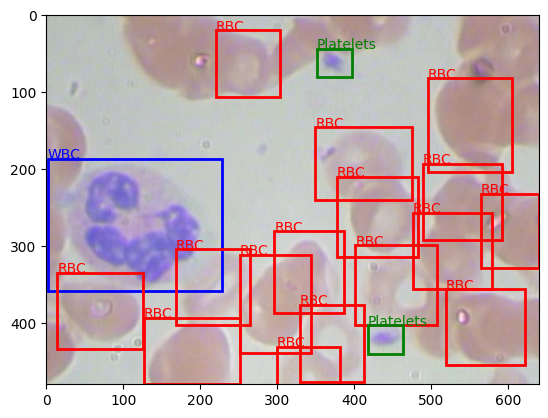

In [11]:
# Визуализация примера
fig, ax = plt.subplots(1)
ax.imshow(image)

color_map = {1: 'red', 2: 'blue', 3: 'green'}
label_map = {1: 'RBC', 2: 'WBC', 3: 'Platelets'}

for box, label in zip(target['boxes'], target['labels']):
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        linewidth=2,
        edgecolor=color_map[label.item()],
        facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(xmin, ymin, label_map[label.item()], color=color_map[label.item()])

plt.show()

##`Подготовка данных`

In [12]:
# Функция перерасчёта разметки
def resize_boxes(boxes, original_size, target_size=(300, 300)):
    """
    Пересчитывает координаты bounding boxes после resize изображения.
    Args:
        boxes: массив [[xmin, ymin, xmax, ymax], ...] в исходных координатах
        original_size: tuple (width, height) исходного изображения
        target_size: tuple (width, height) целевого размера
    Returns:
        Массив boxes в новых координатах
    """
    orig_w, orig_h = original_size
    target_w, target_h = target_size

    scale_x = target_w / orig_w
    scale_y = target_h / orig_h

    resized_boxes = boxes.copy()
    # xmin, xmax — масштабируем по ширине
    resized_boxes[:, 0] *= scale_x  # xmin
    resized_boxes[:, 2] *= scale_x  # xmax
    # ymin, ymax — масштабируем по высоте
    resized_boxes[:, 1] *= scale_y  # ymin
    resized_boxes[:, 3] *= scale_y  # ymax

    return resized_boxes

In [13]:
# Трансформация и нормализация
from torchvision import transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
}

In [14]:
# Создание экземплера объёкта тренировочной выборки
train_dataset = BCCDDataset(
    root_dir='/content/BCCD_Dataset/BCCD',
    txt='train',                        # указывает, какой .txt-файл читать
    transform=data_transforms['train']  # задаёт трансформации
)

# Проверяем, что список файлов загрузился
print(f"Всего изображений в train: {train_dataset.__len__()}")
print(f"Первые 5 ID: {train_dataset.image_ids[:5]}")

Всего изображений в train: 204
Первые 5 ID: ['BloodImage_00001', 'BloodImage_00003', 'BloodImage_00004', 'BloodImage_00005', 'BloodImage_00006']


In [15]:
# Создание экземплера объёкта валидационной выборки
val_dataset = BCCDDataset(
    root_dir='/content/BCCD_Dataset/BCCD',
    txt='val',                          # указывает, какой .txt-файл читать
    transform=data_transforms['val']    # задаёт трансформации
)

# Проверяем, что список файлов загрузился
print(f"Всего изображений в val: {len(val_dataset)}")
print(f"Первые 5 ID: {val_dataset.image_ids[:5]}")

Всего изображений в val: 86
Первые 5 ID: ['BloodImage_00000', 'BloodImage_00002', 'BloodImage_00014', 'BloodImage_00017', 'BloodImage_00028']


In [16]:
# Формирование даталоадеров
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=6,
    shuffle=True,
collate_fn=lambda x: (
        torch.stack([item[0] for item in x]),  # тензор [6, 3, H, W]
        [item[1] for item in x]                # список словарей
    )
)

val_loader = DataLoader(
    val_dataset,
    batch_size=6,
    shuffle=False,
collate_fn=lambda x: (
        torch.stack([item[0] for item in x]),  # тензор [6, 3, H, W]      # Кастомная collate_fn с torch.stack
        [item[1] for item in x]                # список словарей для батча ( 6 словарей в каждом батче)
    )
)

lines_print = [
    'images — тензор размером [6, 3, 480, 640]',
    'targets — список словарей (6 словарей), по одному словарю на каждое изображение в батче',
    'Каждый словарь содержит аннотации для одного изображения с ключами: boxes, labels, image_id.'
]
print('\n'.join(lines_print))

images — тензор размером [6, 3, 480, 640]
targets — список словарей (6 словарей), по одному словарю на каждое изображение в батче
Каждый словарь содержит аннотации для одного изображения с ключами: boxes, labels, image_id.


In [17]:
# Пример одного изображения
print("===Получаем содержимое примера targets изображения===")
for images, targets in train_loader:
    print("Пример изображения из батча и его словарь - targets для данного изображения:")
    print(f"  Bounding boxes: {targets[0]['boxes']}")
    print(f"  Классы (labels): {targets[0]['labels']}")
    print(f"  image_id: {targets[0]['image_id']}")
    break

===Получаем содержимое примера targets изображения===
Пример изображения из батча и его словарь - targets для данного изображения:
  Bounding boxes: tensor([[  3., 346., 123., 464.],
        [165., 153., 285., 271.],
        [359.,   1., 476., 104.],
        [270.,  93., 387., 197.],
        [389., 175., 500., 313.],
        [559.,  51., 640., 168.],
        [492., 423., 610., 479.],
        [ 31., 177., 151., 295.],
        [149.,  43., 256., 132.],
        [246., 433., 353., 480.],
        [394., 114., 525., 217.],
        [469., 211., 577., 329.],
        [295., 338., 325., 369.],
        [ 79.,  48., 115.,  90.],
        [318., 318., 487., 480.]])
  Классы (labels): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 2])
  image_id: BloodImage_00278


In [18]:
# Проверяем размеры батча
for images, labels in train_loader:
    print(f"Размер батча: {images.shape}")  # [6, 3, 480, 640]
    print(f"Размер одного изображения: {images[0].shape}")  # [3, 480, 640]

    # Дополнительная проверка
    print(f"Тип данных изображений: {type(images)}")  # <class 'torch.Tensor'>
    print(f"Диапазон значений пикселей: [{images.min():.3f}, {images.max():.3f}]")
    break  # Выходим после первого батча

print(f'Общее количество батчей: {len(train_loader)}')
print(f'Общее количество изображений в датасете: {len(train_loader.dataset)}')

Размер батча: torch.Size([6, 3, 480, 640])
Размер одного изображения: torch.Size([3, 480, 640])
Тип данных изображений: <class 'torch.Tensor'>
Диапазон значений пикселей: [-1.055, 2.570]
Общее количество батчей: 34
Общее количество изображений в датасете: 204


In [19]:
print(len(val_loader.dataset))

86


## `Создание модели. Transfer Learning | Fine‑Tuning`

In [20]:
#from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [21]:
def create_feature_extraction_model(num_classes):
    # Загружаем предобученную модель
    model = fasterrcnn_resnet50_fpn(pretrained=True)

    # Заменяем голову модели под нужное число классов
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes+1)  # +1 для фона

    # Замораживаем backbone (ResNet50)
    for param in model.backbone.parameters():
        param.requires_grad = False

    return model

# Создаём модель для 3 классов (эритроциты, лейкоциты, тромбоциты)
num_classes = 3
model = create_feature_extraction_model(num_classes)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 184MB/s]


In [22]:
# 3 класса(фон уже добавлен в функции выше):
model = create_feature_extraction_model(num_classes=3)
#model.eval()

print(model.roi_heads.box_predictor)
# FastRCNNPredictor(
#   (cls_score): Linear(in_features=1024, out_features=3, bias=True)
#   (bbox_pred): Linear(in_features=1024, out_features=12, bias=True)
# )


FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=4, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=16, bias=True)
)


In [23]:
# Собираем только обучаемые параметры (только голова модели)
params_to_update = []
for name, param in model.named_parameters():
    if param.requires_grad:
        params_to_update.append(param)

# Создаём оптимизатор и шедулер
optimizer = torch.optim.SGD(params_to_update, lr=0.01, momentum=0.9)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [24]:
# Функция обучения
import time
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    """
    Обучает модель на протяжении одной эпохи.

    Args:
        model: модель для обучения
        optimizer: оптимизатор
        data_loader: DataLoader с обучающими данными
        device: устройство ('cuda' или 'cpu')
        epoch: номер текущей эпохи

    Returns:
        avg_loss: среднее значение потерь за эпоху
    """
    model.train()
    running_loss = 0.0
    start_time = time.time()

    for batch_idx, (images, targets) in enumerate(data_loader):
        # Переносим данные на устройство
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v
                  for k, v in t.items()} for t in targets]

        # Прямой проход и вычисление потерь
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Обратное распространение
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

        # Вывод прогресса каждые 10 батчей
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}, Loss: {losses.item():.4f}")
            # Выводим компоненты потерь для диагностики
            for loss_name, loss_value in loss_dict.items():
                print(f"  {loss_name}: {loss_value.item():.4f}")

    # Рассчитываем среднее значение потерь и время эпохи
    avg_loss = running_loss / len(data_loader)
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch} completed in {epoch_time:.2f}s, Avg Loss: {avg_loss:.4f}")
    return avg_loss


In [25]:
from torchmetrics.detection import MeanAveragePrecision

@torch.no_grad()
def evaluate_detection(model, data_loader, device):
    """
    Валидация модели детекции в режиме eval.

    Args:
        model: модель для валидации
        data_loader: DataLoader с валидационными данными
        device: устройство (CPU/GPU)

    Returns:
        dict с метриками (mAP, AP по классам и т. д.)
    """
    model.eval()  # Режим инференса
    # Инициализируем метрику с корректными параметрами
    metric = MeanAveragePrecision(
        iou_type="bbox",           # тип объектов — bounding boxes
        iou_thresholds=[0.5, 0.75]  # пороги IoU для расчёта
    )

    for images, targets in data_loader:
        # Переносим данные на устройство
        images = list(img.to(device) for img in images)

        # Прямой проход: получаем предсказания
        predictions = model(images)

        # Подготавливаем данные для метрики
        preds = [
            {
                'boxes': p['boxes'].cpu(),
                'scores': p['scores'].cpu(),
                'labels': p['labels'].cpu()
            }
            for p in predictions
        ]
        targets_for_metric = [
            {
                'boxes': t['boxes'].cpu(),
                'labels': t['labels'].cpu()
            }
            for t in targets
        ]

        # Обновляем метрику
        metric.update(preds, targets_for_metric)

    # Получаем итоговые метрики
    result = metric.compute()

    # Выводим основные метрики
    print(f"mAP@0.5: {result['map_50'].item():.4f}")
    print(f"mAP@0.75: {result['map_75'].item():.4f}")
    print(f"COCO mAP (0.5:0.95): {result['map'].item():.4f}")

    return result

## `Обучение модели`

In [26]:
# Устройство
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Параметры обучения
num_epochs = 15  # 10 эпох достаточно для Feature Extraction

# Списки для хранения метрик
train_losses = []
val_losses = []

# Списки для хранения метрик по эпохам
mAP_50_history = []
mAP_75_history = []
COCO_mAP_history = []

print('=== ОБУЧЕНИЕ В РЕЖИМЕ FEATURE EXTRACTION ===')
print(f"Обучаемые параметры: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

=== ОБУЧЕНИЕ В РЕЖИМЕ FEATURE EXTRACTION ===
Обучаемые параметры: 14510115


In [27]:
# Цикл обучения по эпохам
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    # Обучение
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
    train_losses.append(train_loss)

    # Валидация — получаем и метрики, и потери
    val_metrics = evaluate_detection(model, val_loader, device)

    # Сохраняем метрики в списки
    mAP_50_history.append(val_metrics['map_50'].item())
    mAP_75_history.append(val_metrics['map_75'].item())
    COCO_mAP_history.append(val_metrics['map'].item())


Epoch 1/15
Epoch 0, Batch 0, Loss: 3.2842
  loss_classifier: 1.5965
  loss_box_reg: 0.2249
  loss_objectness: 1.3324
  loss_rpn_box_reg: 0.1304
Epoch 0, Batch 10, Loss: 1.6052
  loss_classifier: 0.5817
  loss_box_reg: 0.7374
  loss_objectness: 0.1867
  loss_rpn_box_reg: 0.0995
Epoch 0, Batch 20, Loss: 1.4142
  loss_classifier: 0.4697
  loss_box_reg: 0.7566
  loss_objectness: 0.1137
  loss_rpn_box_reg: 0.0742
Epoch 0, Batch 30, Loss: 1.2324
  loss_classifier: 0.5030
  loss_box_reg: 0.6032
  loss_objectness: 0.0787
  loss_rpn_box_reg: 0.0475
Epoch 0 completed in 27.84s, Avg Loss: 1.5352
mAP@0.5: 0.4225
mAP@0.75: 0.0768
COCO mAP (0.5:0.95): 0.2496

Epoch 2/15
Epoch 1, Batch 0, Loss: 1.0521
  loss_classifier: 0.3913
  loss_box_reg: 0.5559
  loss_objectness: 0.0648
  loss_rpn_box_reg: 0.0401
Epoch 1, Batch 10, Loss: 1.0441
  loss_classifier: 0.3180
  loss_box_reg: 0.6362
  loss_objectness: 0.0470
  loss_rpn_box_reg: 0.0429
Epoch 1, Batch 20, Loss: 0.9444
  loss_classifier: 0.3009
  loss_bo

## `График Lossa и График метрик на эпохах`

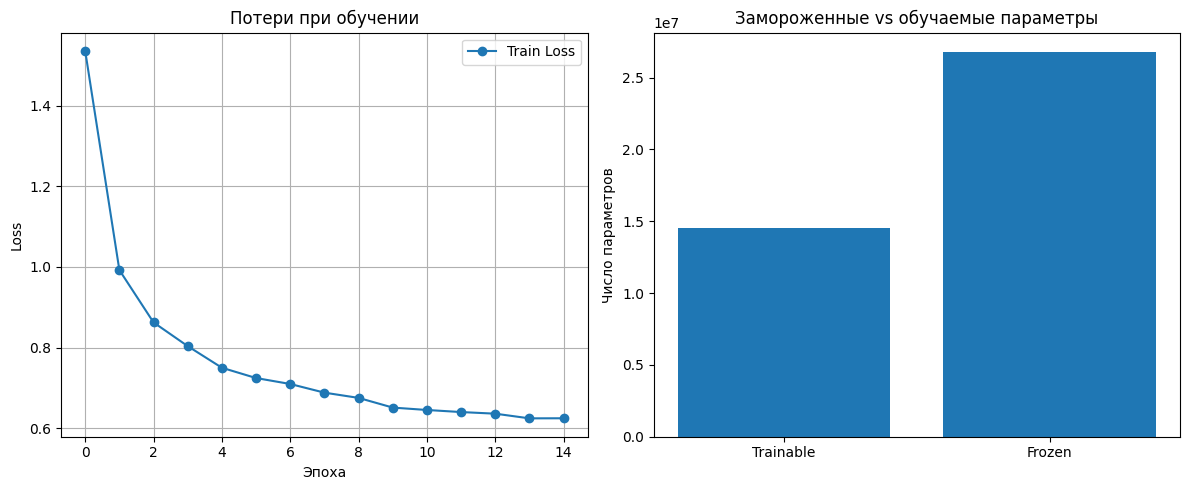

In [28]:
plt.figure(figsize=(12, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
#plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Потери при обучении')
plt.legend()
plt.grid(True)

# Дополнительная информация
plt.subplot(1, 2, 2)
plt.bar(['Trainable', 'Frozen'], [
    sum(p.numel() for p in model.parameters() if p.requires_grad),
    sum(p.numel() for p in model.parameters() if not p.requires_grad)
])
plt.ylabel('Число параметров')
plt.title('Замороженные vs обучаемые параметры')

plt.tight_layout()
plt.show()


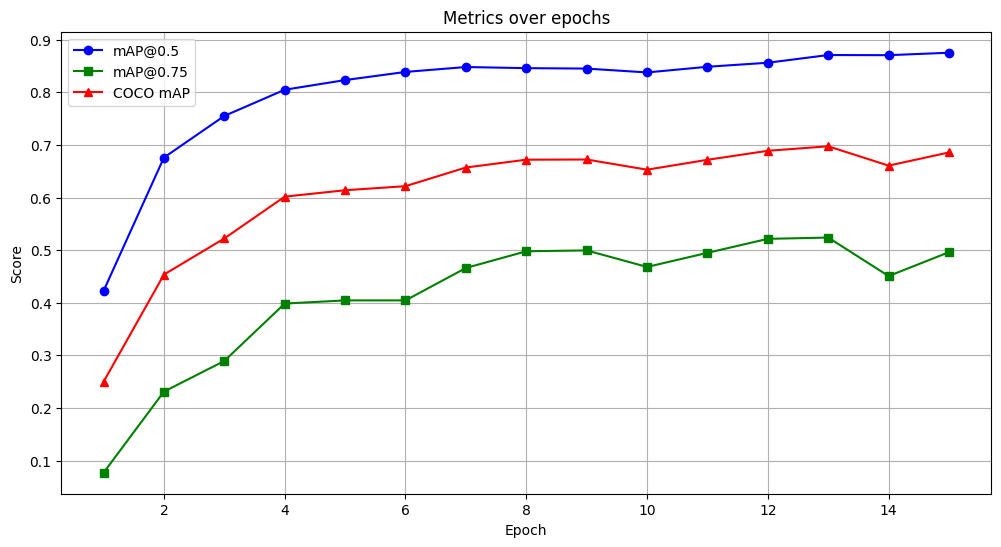

In [29]:
import matplotlib.pyplot as plt

def plot_metrics(mAP_50_history, mAP_75_history, COCO_mAP_history):
    epochs = range(1, len(mAP_50_history) + 1)

    plt.figure(figsize=(12, 6))
    plt.plot(epochs, mAP_50_history, 'b-o', label='mAP@0.5')
    plt.plot(epochs, mAP_75_history, 'g-s', label='mAP@0.75')
    plt.plot(epochs, COCO_mAP_history, 'r-^', label='COCO mAP')

    plt.title('Metrics over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Вызов функции после завершения обучения
plot_metrics(mAP_50_history, mAP_75_history, COCO_mAP_history)

In [30]:
torch.save(model.state_dict(), 'faster_rcnn_feature_extraction.pth')
print("Модель сохранена как 'faster_rcnn_feature_extraction.pth'")

Модель сохранена как 'faster_rcnn_feature_extraction.pth'


## `Некоторые ВЫВОДЫ по метрикам`

In [31]:
def print_metrics(val_metrics):
    mAP_50 = val_metrics['map_50'].item()
    mAP_75 = val_metrics['map_75'].item()
    coco_mAP = val_metrics['map'].item()

    print("📊 РЕЗУЛЬТАТЫ ВАЛИДАЦИИ МОДЕЛИ ДЕТЕКЦИИ 📊")
    print("- " * 60)
    print(f"• mAP@0.5:   {mAP_50:.4f} ({mAP_50 * 100:.1f}%) — высокая точность при мягком пороге IoU≥0.5")
    print(f"• mAP@0.75:  {mAP_75:.4f} ({mAP_75 * 100:.1f}%) — средняя точность при строгом пороге IoU≥0.75")
    print(f"• COCO mAP:  {coco_mAP:.4f} ({coco_mAP * 100:.1f}%) — сбалансированная оценка по стандарту COCO")
    print("- " * 60)

    if mAP_50 > 0.8:
        print("✅ Модель отлично находит объекты (mAP@0.5 > 80%)")
    if mAP_75 < 0.5:
        print("⚠️ Средняя точность локализации (mAP@0.75 ~= 50%) — требуется доработка")
    if coco_mAP > 0.6:
        print("🔧 Общий результат приемлемый (COCO mAP > 60%)")


print_metrics(val_metrics)


📊 РЕЗУЛЬТАТЫ ВАЛИДАЦИИ МОДЕЛИ ДЕТЕКЦИИ 📊
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
• mAP@0.5:   0.8753 (87.5%) — высокая точность при мягком пороге IoU≥0.5
• mAP@0.75:  0.4961 (49.6%) — средняя точность при строгом пороге IoU≥0.75
• COCO mAP:  0.6857 (68.6%) — сбалансированная оценка по стандарту COCO
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
✅ Модель отлично находит объекты (mAP@0.5 > 80%)
⚠️ Средняя точность локализации (mAP@0.75 ~= 50%) — требуется доработка
🔧 Общий результат приемлемый (COCO mAP > 60%)


In [32]:
def print_interpretation(val_metrics):
    mAP_50 = val_metrics['map_50'].item()
    mAP_75 = val_metrics['map_75'].item()

    print("АНАЛИЗ КАЧЕСТВА ЛОКАЛИЗАЦИИ ОБЪЕКТОВ")
    print("=" * 60)
    print(f"• Высокая способность обнаружения объектов: mAP@0.5 = {mAP_50:.4f} ({mAP_50 * 100:.1f} %)")
    print(f"• Ограниченная точность локализации: mAP@0.75 = {mAP_75:.4f} ({mAP_75 * 100:.1f} %)")
    print()
    print("Интерпретация результатов:")
    print("- Модель демонстрирует высокую эффективность в обнаружении объектов даже при умеренных требованиях к точности локализации.")
    print("- Обнаруженные bounding boxes могут иметь небольшие отклонения от истинных границ (незначительные сдвиги,")
    print("  увеличение или уменьшение размеров), однако это не препятствует корректному обнаружению объектов.")
    print("- Выявлена проблема с точной локализацией: модель не обеспечивает достаточного уровня детализации границ объектов.")
    print()
    print("Рекомендации по применению:")
    print("- Оптимально подходит для задач подсчёта объектов и фильтрации.")
    print("- Не рекомендуется для областей с высокими требованиями к точности локализации:")
    print("  • медицинская диагностика;")
    print("  • системы автономного вождения;")
    print("  • задачи измерения физических размеров объектов.")
    print("=" * 60)


print_interpretation(val_metrics)


АНАЛИЗ КАЧЕСТВА ЛОКАЛИЗАЦИИ ОБЪЕКТОВ
• Высокая способность обнаружения объектов: mAP@0.5 = 0.8753 (87.5 %)
• Ограниченная точность локализации: mAP@0.75 = 0.4961 (49.6 %)

Интерпретация результатов:
- Модель демонстрирует высокую эффективность в обнаружении объектов даже при умеренных требованиях к точности локализации.
- Обнаруженные bounding boxes могут иметь небольшие отклонения от истинных границ (незначительные сдвиги,
  увеличение или уменьшение размеров), однако это не препятствует корректному обнаружению объектов.
- Выявлена проблема с точной локализацией: модель не обеспечивает достаточного уровня детализации границ объектов.

Рекомендации по применению:
- Оптимально подходит для задач подсчёта объектов и фильтрации.
- Не рекомендуется для областей с высокими требованиями к точности локализации:
  • медицинская диагностика;
  • системы автономного вождения;
  • задачи измерения физических размеров объектов.


##`Визуализация`

In [72]:
# Экземпляр датасета для визуализации валидационных данных
val_dataset_visualization = BCCDDataset(
    root_dir=root,
    txt='val',
    transform=data_transforms['val']  # использую те же трансформации, что и раньше
)

print(f'Размер train: {len(val_dataset_visualization)}')

# Пример (6 изображение из val листа)
image, target = blood_img[6]

print(f'Image size: {image.size}')
print(f'Boxes: {target["boxes"]}')
print(f'Labels: {target["labels"]}')

# Формирую датасет первых 6 изображений
val_dataset_visualization.image_ids = val_dataset_visualization.image_ids[:6]


Размер train: 86
Image size: (640, 480)
Boxes: tensor([[ 23., 137., 255., 423.],
        [441., 324., 575., 423.],
        [372., 192., 468., 279.],
        [305., 213., 401., 300.],
        [226., 288., 324., 439.],
        [313., 318., 408., 414.],
        [282., 384., 377., 480.],
        [446.,  97., 567., 206.],
        [440.,   1., 561.,  96.],
        [214., 107., 331., 198.],
        [298.,  85., 435., 211.],
        [  7.,  76., 133., 197.],
        [  1.,   1., 115.,  94.],
        [286.,   1., 394.,  65.],
        [154.,  13., 289., 127.],
        [452., 415., 493., 449.],
        [479., 155., 575., 242.],
        [135., 393., 231., 480.]])
Labels: tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1])


In [73]:
val_dataset_visualization.image_ids

['BloodImage_00000',
 'BloodImage_00002',
 'BloodImage_00014',
 'BloodImage_00017',
 'BloodImage_00028',
 'BloodImage_00029']

In [74]:
import matplotlib.pyplot as plt

def visualize_dataset_predictions(model, dataset, device, confidence_threshold=0.5):
    """
    Визуализация предсказаний модели на val данных

    """
    model.eval()
    class_names = ['background', 'RBC', 'WBC', 'Platelets']

    # Сетка для визуализации: 6 строк × 2 столбца (истинные vs предсказанные)
    fig, axes = plt.subplots(6, 2, figsize=(15, 30))

    for i in range(len(dataset)):
        # Изображение и истинные аннотации из датасета
        image, target = dataset[i]
        image_tensor = image.unsqueeze(0).to(device)  # добавление batch dimension

        # Предсказания модели
        with torch.no_grad():
            predictions = model(image_tensor)
            pred = predictions[0]  # берём первый (и единственный) элемент

        # Конвертация тензора изображения в numpy для matplotlib
        # Нормализация: умножаем на стандартные отклонения и прибавляем средние значения
        if hasattr(dataset.transform, 'transforms') and any(isinstance(t, transforms.Normalize) for t in dataset.transform.transforms):
            # Если есть нормализация, восстанавливаем исходные значения
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            image_np = image.cpu().permute(1, 2, 0).numpy() * std + mean
            image_np = (image_np * 255).astype(np.uint8)
        else:
            # Если нормализации нет, просто масштабируем до [0, 255]
            image_np = (image.cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)

        # --- Левый столбец: истинные аннотации ---
        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title(f'Image {i+1} — Истинные', fontsize=12, pad=20)  # уменьшенный шрифт и увеличенный отступ
        axes[i, 0].axis('off')

        # Отображение истинных bounding boxes
        true_boxes = target['boxes'].numpy()
        true_labels = target['labels'].numpy()

        for box, label in zip(true_boxes, true_labels):
            x_min, y_min, x_max, y_max = box
            width, height = x_max - x_min, y_max - y_min
            rect = plt.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor='green', facecolor='none'
            )
            axes[i, 0].add_patch(rect)
            # Подпись внутри box для Ground Truth (чтобы тоже не накладывалась)
            text_x = x_min + 5
            text_y = y_min + 15
            axes[i, 0].text(
                text_x, text_y,
                class_names[label],
                color='green', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2')
            )

        # --- Правый столбец: предсказания модели ---
        axes[i, 1].imshow(image_np)
        axes[i, 1].set_title(f'Image {i+1} — Предсказанные', fontsize=12, pad=20)  # уменьшенный шрифт и увеличенный отступ
        axes[i, 1].axis('off')

        # Предсказания по порогу уверенности
        mask = pred['scores'] > confidence_threshold
        pred_boxes = pred['boxes'][mask].cpu().numpy()
        pred_labels = pred['labels'][mask].cpu().numpy()
        pred_scores = pred['scores'][mask].cpu().numpy()

        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            x_min, y_min, x_max, y_max = box
            width, height = x_max - x_min, y_max - y_min

            # Формирование прямоугольника
            rect = plt.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            axes[i, 1].add_patch(rect)

            # Текст снизу от bounding box, уменьшенный шрифт, с закруглённым фоном
            axes[i, 1].text(
                x_min, y_max + 5,  # Смещение вниз от box (вместо y_min - 10)
                f'{class_names[label]}: {score:.2f}',
                color='red', fontsize=9,  # Уменьшенный шрифт
                bbox=dict(
                    facecolor='yellow',
                    alpha=0.7,
                    boxstyle='round,pad=0.3'  # Закруглённые углы у фона подписи
                )
            )

    plt.tight_layout()
    plt.show()

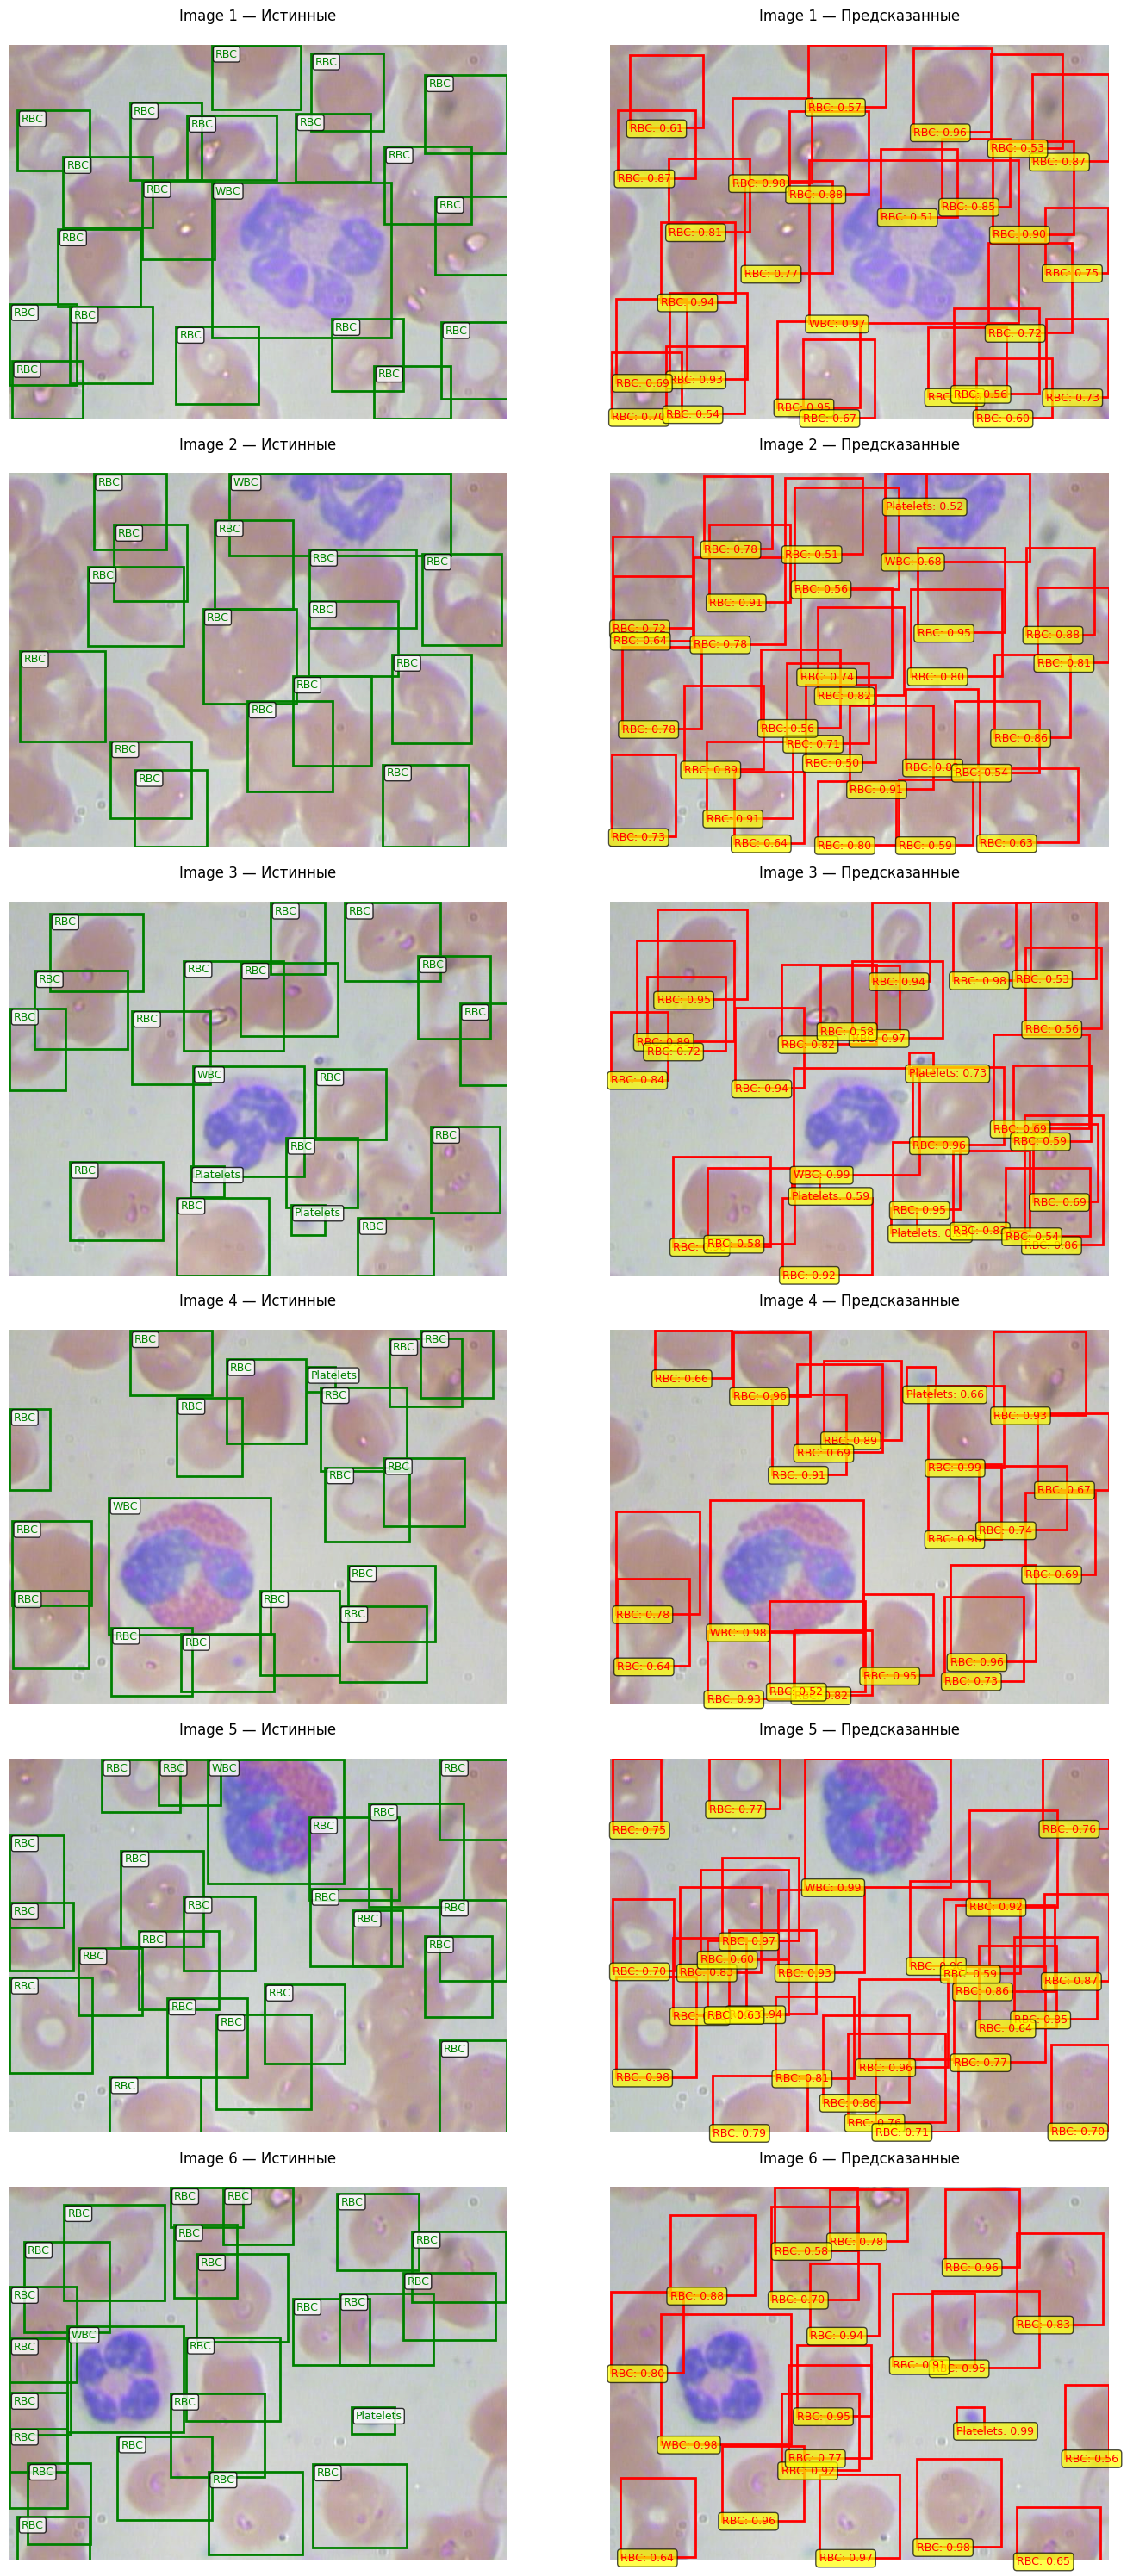

In [75]:
# Визуализация сравнения
visualize_dataset_predictions(
    model=model,
    dataset=val_dataset_visualization,
    device=device,
    confidence_threshold=0.5
)

## `Некоторые ВЫВОДЫ по визуализации`

In [71]:
print("АНАЛИЗ ВИЗУАЛИЗАЦИИ ПРЕДСКАЗАНИЙ МОДЕЛИ:\n")
print("=" * 150)
print("На полученных изображениях определяются явление множественных предсказаний для одного объекта\nс разной оценкой уверенности. Думаю что причины следующие:\n")

print("1. Особенности датасета:")
print("   • Клетки крови (особенно эритроциты) расположены близко друг к другу и часто перекрываются, что затрудняет однозначную локализацию.")
print("   • Эритроциты, особенно тромбоциты значительно меньше лейкоцитов, что усложняет их детектирование и повышает вероятность ложных срабатываний.")
print("   • В истинных разметках явно присутствуют пропуски: некоторые объекты (особенно эритроциты и тромбоциты) не аннотированы.")
print("   • Отмечено наложение истинных аннотаций на соседние клетки, особенно в зонах скопления эритроцитов.\n")

print("2. Параметры и архитектура модели:")
print("   • Текущие гиперпараметры обучения могут быть неоптимальными, что приводит к избыточным предсказаниям.")
print("   • Существующая стратегия извлечения признаков (feature extraction|Fine‑Tuning)")
print("     возможно, недостаточно гибкая для различения тесно расположенных и схожих по виду клеток.\n")

print("ВОЗМОЖНЫЕ РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:")
print("   • Настроить гиперпараметры модели (порог уверенности?, параметры NMS?).")
print("   • Рассмотреть применение трансферного обучения с заменой или тонкой настройкой feature extractor под специфику датасета.")
print("   • Проверить и улучшить качество разметки (устранить пропуски и наложения).")
print("=" * 150)

АНАЛИЗ ВИЗУАЛИЗАЦИИ ПРЕДСКАЗАНИЙ МОДЕЛИ:

На полученных изображениях определяются явление множественных предсказаний для одного объекта
с разной оценкой уверенности. Думаю что причины следующие:

1. Особенности датасета:
   • Клетки крови (особенно эритроциты) расположены близко друг к другу и часто перекрываются, что затрудняет однозначную локализацию.
   • Эритроциты, особенно тромбоциты значительно меньше лейкоцитов, что усложняет их детектирование и повышает вероятность ложных срабатываний.
   • В истинных разметках явно присутствуют пропуски: некоторые объекты (особенно эритроциты и тромбоциты) не аннотированы.
   • Отмечено наложение истинных аннотаций на соседние клетки, особенно в зонах скопления эритроцитов.

2. Параметры и архитектура модели:
   • Текущие гиперпараметры обучения могут быть неоптимальными, что приводит к избыточным предсказаниям.
   • Существующая стратегия извлечения признаков (feature extraction|Fine‑Tuning)
     возможно, недостаточно гибкая для различения 